# PyDCNN - Handwritten Digit Classification using PyTorch

This notebook will guide you through the process of creating, training and evaluating a Deep Convolutional Neural Network using the PyTorch library.

We'll be training this network using the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database) - a famous dataset used for training machine learning models to classify handwritten digits.

---
#1) Import libraries for PyTorch

Let's import the libraries we'll need for this project:



In [ ]:
# pytorch imports
import torch
from torch import nn, optim
from torchvision.transforms import Compose, ToTensor, Lambda
import torchvision.transforms.functional as F

# the dataset we'll be using
from torchvision.datasets import MNIST

# DataLoader will automatically handle batching for us
from torch.utils.data import DataLoader

# other libraries
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math

---
# 2) Importing our dataset

In machine learning, we often divide our dataset into two distinct pieces: the training set and the test set. This step is highly important to prevent data leakage. If a model is tested on the same data it's been trained on, it can lead to **deceptively high results** when we evaluate our model.

Thankfully, torchvision datasets allow us to automatically perform the train-test split on our dataset.

Since we'll be training on images, we'll also apply a transform upon importing our data to automatically convert the image data into PyTorch tensors:

In [ ]:
# create simple transform to convert the image data into PyTorch Tensors
my_transform = Compose([ToTensor()])

# [!] uncomment to invert pixel values
#my_transform = Compose([ToTensor(), Lambda(lambda x: 1 - x)])

## GET TRAINING AND TEST DATA
training_data = MNIST(
      root="./",
      download=True,
      train=True, # specify training data
      transform=my_transform # applies our transform we declared above
    )

test_data = MNIST(
          root="./",
      download=True,
      train=False, # specify test data
      transform=my_transform # applies our transform we declared above
    )

---
## 3) Data Exploration

 We can preview a subset of the training data to get a better idea of what we're working with. The MNIST dataset is comprised of **28 x 28 images of handwritten digits.**

 Note that the torchvision version of MNIST includes the digits formatted in white on a black background. If we end up running predictions on images of black digits on a white background (as many real-world images of handwritten text tend to be), **we'll need to invert the color values first** to get accurate predictions.

If that sounds like a hassle for your intended use case, there's a line in step 2 you can uncomment that will invert the images in our dataset as part of the transform. I haven't tested it myself, but it's possible that doing this could affect the final performance of the network.

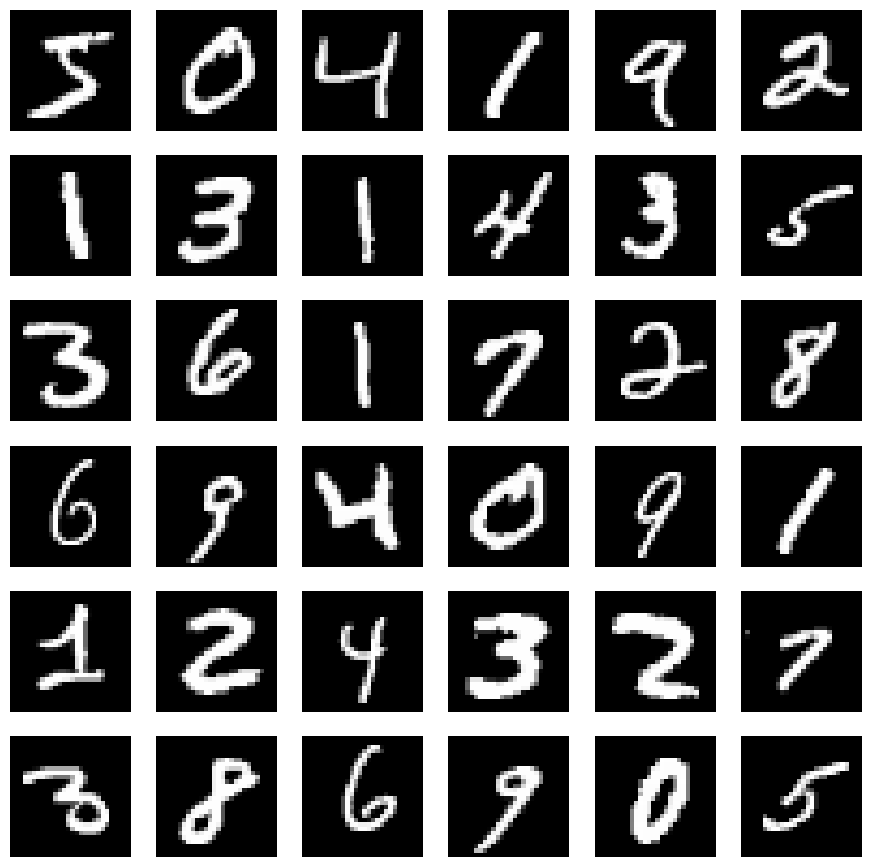

In [ ]:
img_count = 36  # how many images to preview from our training dataset

# calculate square dimensions for subplots
dim = math.ceil(math.sqrt(img_count))

fig, axes = plt.subplots(dim, dim, figsize=(11,11))

for i in range(img_count):
  # isolate corresponding subplot
  ax = axes[i//dim%dim, i%dim]

  # put ith image from training_data into subplot
  img = F.to_pil_image(training_data[i][0]) # convert from tensor to PIL Image
  ax.imshow(img, cmap='Greys_r', interpolation='none')
  ax.axis('off')

  # [!] uncomment to reveal the labels for each image
  #ax.set_title(training_data[i][1])

plt.show()


As you can see above, given the low resolution and the various styles of handwriting, it may be difficult even for a human to determine which number is represented in some of the samples.

### Examining the data distribution

It's worth taking a look at our training data to see how many samples of each class (digit) is included. If there's a disproportionate amount of certain classes, that could negatively affect our results:

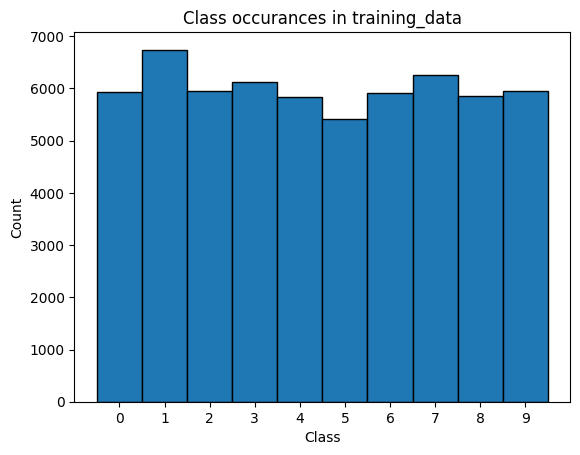


Total number of samples: 60000
Median class: 4
Most frequent class: 1 (occurs 6742 times)
Least frequent class: 5 (occurs 5421 times)


In [ ]:
# plot labels from training data in a histogram
plt.hist(training_data.targets, bins=np.arange(11)-0.5, edgecolor='black')

plt.xticks(range(10)) # line up ticks with bins
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class occurances in training_data")
plt.show()

# show some metrics on the training data
print(f"\nTotal number of samples: {len(training_data)}")
print(f"Median class: {int(np.median(training_data.targets))}")
print(f"Most frequent class: {int(np.bincount(training_data.targets).argmax())} (occurs {np.bincount(training_data.targets).max()} times)")
print(f"Least frequent class: {int(np.bincount(training_data.targets).argmin())} (occurs {np.bincount(training_data.targets).min()} times)")

From a glance, we can see that there's a fairly uniform distribution of all classes in training_data, **which is what we're looking for** in a good training set. An unbalanced distribution of classes could cause our model to become overfit on those overrepresented classes during training.

Since this version of the MNIST dataset comes with prepackaged training and test splits, It's good practice to verify that each split contains an appropriate number of samples:

In [ ]:
print(f"Training samples: {len(training_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 60000
Test samples: 10000


Looks like we have a 6:1 ratio of training to test samples. This is perfectly adequate for our use-case, since we'll want to use the majority of samples for training, while leaving enough samples to effectively evaluate the model after training.

---
## 4) Building the model

Here's the part where we actually design our model and define it's architecture. This involves creating a class that inherits from *nn.Module*, which handles a lot of the core functionality for us. Then, we lay out our architecture layer by layer inside the *\_\_init\_\_()* function. We also create functions for completing a forward pass, running predictions and training the model.

### CNN Basics
The architecture of any CNN includes a few different kinds of layers:

- **Convolutional layers** apply convolutional filters to an image. They have a number of channels, each with different parameters to apply to the input image. These parameters are trained as weights during the training phase of the model.
- **Activation layers** are layers that decide if the previous neuron's information should be passed on, or supressed. This introduces **non-linearity** in our network, which helps them recognize complex patterns in the data. They're often positioned after every convolutional layer.
- **Pooling layers** reduce the dimensions of images that pass through them. Max pooling layers specifically only keep the maximum values present in a given radius. These are applied after a number of convolutional layers (and activation layers), both gradually reducing parameter count and helping the model to **focus on the "bigger picture."**
- A CNN is terminated by a sequence of **linear layers**, which are the traditional layers you would find in a fully-connected neural network. These basically take the results of the convolutional portion, and interpret them into a final prediction. Because their inputs are received as 1-dimensional vectors, we'll need to flatten our 2D image data before passing it into the linear layers.

### Loss Function (AKA Error Function)
The loss function we're using here is called **Cross-entropy loss.** It's used during training to calculate the difference between the model's predicted probability scores for each digit, and the true value of the digit. Simply put, the more accurate the prediction, the lower the loss value will be. This loss value is then used to decide how the much the weights should be adjusted during a training pass.

### Optimizer
The optimizer we're using is called **Adam**, short for *Adaptive Moment Estimation.* The optimizer is the algorithm that **updates the parameters of the neural network during training.** It does this by calculating the gradient, which is a tensor representing the direction of the steepest error, and adjusting the weights to move away from that direction in order to minimize loss/error.

Adam is a solid choice because it will automatically and selectively adjust the learning rate applied to each parameter, which can help speed up the training process. If you're willing to take the time to adjust your optimizer to maximize performance, you could potentially squeeze out better accuracy scores using an optimizer like SGD (Stochastic Gradient Descent.)

### Designing the architecture
![PyDCNN Architecture](https://raw.githubusercontent.com/bchafe/PyDCNN/refs/heads/main/images/architecture.png)
The architecture here draws inspiration from [VGGNet](https://en.wikipedia.org/wiki/VGGNet), specifically in stacking multiple 3x3 convolutional layers (each followed by ReLU activation layers) before applying max pooling. VGGNet shown that stacking 3x3 convolutional layers can be used effectively in place of larger convolutional kernels at a lower compute cost.

I opted to keep things simple by always using padding of size 1. When paired with a 3x3 convolution kernel, this ensures that pixels at the edge of the image aren't discarded with each pass through the convolutional layers.

I spent some time optimizing the values here for the convolutional and linear layers. For the convolutional layers I found that stepping up to 32 channels seemed to be the optimal channel count for this architecture with MNIST data.

The result is a relatively small and simple network that performs well at classifying handwritten digits.



# Now back to the code...
The code block below contains our model definition:

In [ ]:
## CLASS DEFINITION FOR OUR MODEL
class PyDCNN(nn.Module):
  def __init__(self, learning_rate=0.00015):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Conv2d(1, 6, 3, padding=1),
          # 1 input channel, 6 output channels, kernel size of 3, padding of 1
          # padding of 1 on each side -> (28 + 1 + 1 (- 3 + 1)) = 28 by 28
        nn.ReLU(), # ReLU activation layer after each convolutional layer

        nn.Conv2d(6, 16, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(16, 32, 3, padding=1),
        nn.ReLU(),

        nn.MaxPool2d(2, stride=2), # max pooling layer
          # MaxPool w/ stride of 2 cuts dimensions in half
          #28 by 28 -> 14 by 14

        nn.Conv2d(32, 32, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(32, 32, 3, padding=1),
        nn.ReLU(),

        nn.Conv2d(32, 32, 3, padding=1),
        nn.ReLU(),

        nn.MaxPool2d(2, stride=2),
          # 14 by 14 -> 7 by 7

        nn.Flatten(), # flatten our image tensors for linear processing

        # Final linear layers
          # 5 layers here worked the best for me
          # we get 1568 from (7 * 7) * 32 channels
        nn.Linear(1568,700),
        nn.Linear(700,300),
        nn.Linear(300,100),
        nn.Linear(100,60),
        nn.Linear(60,10) # final layer outputs 10 (for our 10 classes)
    )

    # set our loss function (cross-entropy for classification)
    self.loss = nn.CrossEntropyLoss()

    # set up our optimizer (adaptive moment estimation)
    self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

  # forward pass function
  def forward(self, input):
    # pass input data to layers
    return(self.layers(input))

  # prediction function
  def predict(self, input):
    # run a forward pass with gradient descent disabled
    with torch.no_grad():
      return torch.argmax(self.forward(input), dim=-1) # return class w/ highest probability score

  # fit (training) function
  def fit(self, input, label):
    # reset gradient to zero for params
    self.optimizer.zero_grad()

    # run forward pass, get prediction
    predicted = self.forward(input)

    ## BACKPROPAGATION
    # calculate loss using prediction and label
    loss = self.loss(predicted, label)

    # propagate loss backwards
    loss.backward()

    # update params according to loss
    self.optimizer.step()

    # return loss value
    return loss.item()




---
## 5) Setting our hyperparameters

Hyperparameters are the variables we specify to **decide how our model will be configured and trained.**

**Epochs** are the number of training iterations. **Batch size** is the number of samples we train our model on before updating the weights/parameters. The **learning rate** determines how much the model's weights are adjusted during each epoch.

After testing different values, I had the best performance using a batch size of 16 and a learning rate around 0.00015. I got the best results by training for 60 epochs, and that took about 30 minutes to complete on a T4 runtime in Google Colab.

In [ ]:
## SET HYPERPARAMETERS
EPOCHS = 60
BATCH_SIZE = 16
LEARNING_RATE=0.00015

### Weights and Biases
If you have an account for Weights and Biases, you can run this code cell and put in your API key. If you don't care to use it, feel free to skip this code cell.

In [ ]:
import wandb

# weights and biases config
config = {
    "epochs": 50,
    "batch_size": 16,
    "lr": 0.0002,
    "dataset": "MNIST",
    "architecture": "PyDCNN"
}

# create our weights and biases project called "MNIST-PyDCNN"
run = wandb.init(project="MNIST-PyDCNN", config=config)

---
## 6) Initialize our model

Now it's time to initialize our model. This code block will automatically pass in the learning rate we set above.

If you're running this notebook on a device with CUDA cores, the code here will try to load it onto device 'cuda' for increased performance. Otherwise it will be assigned to device 'cpu'.

In [ ]:
## MODEL INITIALIZATION
# instantiate our model
cnn = PyDCNN(learning_rate = LEARNING_RATE)

# use cuda if available for faster compute (requires T4 runtime or greater)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn.to(device)
print(f"Model loaded on device '{next(cnn.parameters()).device}'")

## CREATE DATALOADERS
# num_workers is how many threads to use
training_dataloader = DataLoader(training_data, batch_size = BATCH_SIZE, num_workers=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=16, shuffle=True)

Model loaded on device 'cpu'


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


You might notice a warning after running this code block, specifically about the **number of worker processes** assigned to our DataLoaders. If you're running this notebook locally and you're unsure about the performance on your own system, you can lower the *num_workers* keyword argument to the recommended value of 2. If you're running this notebook on Google Colab, I would recommend leaving it at 16.

---

## 7) Training our model

If you'd like to train the model yourself, feel free to run this code block. If you'd rather import a pre-trained version for the sake of testing and evaulation, you can skip to step 8.

If you're running this notebook in Google Colab, Google gives users free access to T4 GPU runtimes for about a few hours. I'd recommend switching your runtime before running this code block to speed up training:

In [ ]:
# check if we're using weights and biases
WANDB = False
try:
  if run:
    print("using wandb...")
    WANDB = True
except:
  print("not using wandb...")


## TRAINING
print("Begin training:")

# for each epoch
for i in tqdm(range(EPOCHS)):

  # initialize total_loss to 0
  total_loss = 0

  # for each input label pair in current batch
  for input, label in training_dataloader:

    # set input and label to use the device we selected earlier
    input = input.to(device)
    label = label.to(device)

    # fit using current input label pair, add loss to total_loss
    total_loss += cnn.fit(input,label)

  # calculate average loss
  avg_loss = total_loss / len(training_dataloader)

  # print epoch number, average loss
  print(f"EPOCH {1+i}: {avg_loss:7f}")

  # if using wanbd, log training loss for current epoch
  if WANDB:
    wandb.log({"epoch":i+1, "training_loss":avg_loss})

# finish run for wandb
if WANDB: run.finish()
print("Training complete!")

not using wandb...
Begin training:


  2%|▏         | 1/60 [00:18<18:09, 18.46s/it]

EPOCH 1: 0.284545


  3%|▎         | 2/60 [00:37<17:58, 18.59s/it]

EPOCH 2: 0.074220


...

EPOCH 58: 0.003811


 98%|█████████▊| 59/60 [18:31<00:18, 18.70s/it]

EPOCH 59: 0.002958


100%|██████████| 60/60 [18:50<00:00, 18.84s/it]

EPOCH 60: 0.003837
Training complete!


### Average Loss

If everything is working as intended, you should see the average loss trending down over time.

I've found that the last 20 epochs begin to show the average loss occasionally shooting up around .1%. This often isn't a good sign, as it can mean the model is beginning to overfit to the data. With that being said, those last 20 epochs definitely make a difference in the final result, as going 5 epochs higher and lower has given me models with worse scores during evaluation.

---
## 8) Exporting/Importing our model (Optional)

If you'd like to run this model as part of an external project, you can run the code block below to export the model to a '.pkl' file. If you're using Google Colab, you can then click the folder icon in the menu bar on the left to view and download the exported model (PyDCNN.pkl)


In [ ]:
## EXPORT MODEL
export_path="./PyDCNN.pkl"

# export pkl file
torch.save(cnn, export_path)
print("Export complete!")

Export complete!


### Importing

Similarly, you can download and import a [pre-trained version](https://github.com/bchafe/PyDCNN/blob/main/PyDCNN.pkl) of the model if you'd like to evaluate the model without training it yourself.

To upload the model in Google Colab, click the folder icon in the menu bar on the left to view the files included with this notebook. Drag and drop the 'PyDCNN.pkl' file into the files tab to upload it. Once it's uploaded, run this code block to finish importing the model:

In [ ]:
## IMPORT MODEL
import_path="./PyDCNN.pkl"

# import pkl file as cnn
cnn = torch.load(import_path, weights_only=False, map_location=torch.device(device))
print(f"Model loaded on device '{next(cnn.parameters()).device}'")
print("Import complete!")

Model loaded on device 'cpu'
Import complete!


---
# 9) Evaluating our model
Now that our model is trained using the training dataset, we'll evaluate our model to assess it's performance.

Run the code block below to run the evaluation of our model.

In [ ]:
## EVALUATION

# initialize count of correct predictions
total_correct = 0
positive = [[0, 0] for _ in range(10)]
prevalence = [0] * 10

# for each batch in our test data
for input, label in tqdm(test_dataloader):

  # set input and label to current device (cuda or cpu)
  input = input.to(device)
  label = label.to(device)

  # run prediction on input
  predictions = cnn.predict(input)

  # for every prediction for this batch (since our batch size is 16)
  for i in range(len(predictions)):

    # increment prevalence
    prevalence[label[i]] += 1

    # if prediction is correct
    if(predictions[i] == label[i]):

      # increment true positive count for given digit
      positive[predictions[i]][0] += 1
      total_correct += 1

    # otherwise increment false positive count for given digit
    else:
      positive[predictions[i]][1] += 1


## SHOW RESULTS
# ansi colors (for pretty results)
colors = {
    'red': '\033[91m',
    'green': '\033[92m',
    'yellow': '\033[93m',
    'blue': '\033[94m',
    'magenta': '\033[95m',
    'cyan': '\033[96m',
    'reset': '\033[0m'
}

print("\n\n" + "="*30)
print("EVALUATION RESULTS")
print("="*30)

# print accuracy
print(f"\nACCURACY (across all classes): {colors['green']}{total_correct / (len(test_data))}{colors['reset']}")

# get precision, recall, f1 for each digit
precision = [0] * 10
recall = [0] * 10
f1 = [0] * 10

for i in range(10):
  p = positive[i][0] / (positive[i][0] + positive[i][1])
  r = positive[i][0] / prevalence[i]

  # store results in lists
  precision[i] = p
  recall[i] = r
  f1[i] = 2 * (p * r) / (p + r)


print("\nPRECISION:")
print(f"Best score: {colors['green']}{precision.index(max(precision))} ({max(precision):.4f}){colors['reset']}")
print(f"Worst score: {colors['yellow']}{precision.index(min(precision))} ({min(precision):.4f}){colors['reset']}")
print("-"*30)
for i in range(10):
  print(f"\tClass {i}: {precision[i]:.4f}")

print("\n\nRECALL:")
print(f"Best score: {colors['green']}{recall.index(max(recall))} ({max(recall):.4f}){colors['reset']}")
print(f"Worst score: {colors['yellow']}{recall.index(min(recall))} ({min(recall):.4f}){colors['reset']}")
print("-"*30)
for i in range(10):
  print(f"\tClass {i}: {recall[i]:.4f}")

print("\n\nF1-SCORE:")
print(f"Best score: {colors['green']}{f1.index(max(f1))} ({max(f1):.4f}){colors['reset']}")
print(f"Worst score: {colors['yellow']}{f1.index(min(f1))} ({min(f1):.4f}){colors['reset']}")
print("-"*30)
for i in range(10):
  print(f"\tClass {i}: {f1[i]:.4f}")

100%|██████████| 625/625 [00:12<00:00, 48.89it/s]



EVALUATION RESULTS

ACCURACY (across all classes): 0.9929

PRECISION:
Best score: 0 (0.9980)
Worst score: 8 (0.9857)
------------------------------
	Class 0: 0.9980
	Class 1: 0.9956
	Class 2: 0.9971
	Class 3: 0.9882
	Class 4: 0.9888
	Class 5: 0.9922
	Class 6: 0.9969
	Class 7: 0.9903
	Class 8: 0.9857
	Class 9: 0.9960


RECALL:
Best score: 1 (0.9982)
Worst score: 9 (0.9802)
------------------------------
	Class 0: 0.9959
	Class 1: 0.9982
	Class 2: 0.9922
	Class 3: 0.9950
	Class 4: 0.9919
	Class 5: 0.9933
	Class 6: 0.9916
	Class 7: 0.9961
	Class 8: 0.9938
	Class 9: 0.9802


F1-SCORE:
Best score: 0 (0.9969)
Worst score: 9 (0.9880)
------------------------------
	Class 0: 0.9969
	Class 1: 0.9969
	Class 2: 0.9947
	Class 3: 0.9916
	Class 4: 0.9903
	Class 5: 0.9927
	Class 6: 0.9942
	Class 7: 0.9932
	Class 8: 0.9898
	Class 9: 0.9880


### Accuracy
Accuracy represents the proportion of correct predictions out of all predictions. Since this model is performing classification for 10 separate classes, this makes accuracy a good metric for understanding the overall performance of the model.

For our use case, we can understand accuracy as:
>For every digit we predicted, how many of them did we predict correctly?

The best results I've gotten with this model is **99.29% accuracy.** Given this score, we can assume that for every 1000 digits we classify using this model, about 7 of them will be incorrectly classified.

---
### Other performance metrics
Note that the other metrics listed here are **more suited to evaluating binary classification problems**, rather than multi-class classification. I've included them regardless, as they can help us understand which digits the model performs better/worse at classifying.

#### Precision
Precision represents the proportion of true positives to all predicted positives (for a given class). This is a good metric to try and maximize if your use case benefits from prefering false negatives over false positives.

In our use case, we can understand precision as:

>For every instance this model predicted as *\<digit\>*, how many of them were actually *\<digit\>*?

In the highest scoring version of PyDCNN that I've trained, I've found the best precision score was for digit 0 (99.8%), and the worst was for digit 8 (98.57%). We can assume that for every 1000 digits this model classifies as a '0',  **around 2 of those will not actually be a '0'.**

#### Recall (AKA sensitivity)
Recall represents the proportion of predicted positives to all true positives (for a given class). This is a good metric to try and maximize if your use case benefits from prefering false positives to false negatives.

In our use case, we can understand recall as:

>For every instance of *\<digit\>*, how many did the model predict to be *\<digit\>*?

The best recall score for my model was for digit 1 (99.82%), and the worst was for digit 9 (98.02%). We can assume that for every 1000 '1's we classify with this model, **around 2 of them will be incorrectly classified** as something other than '1'.

#### F1-Score
F1-score is a metric that represents the harmonic mean of precision and recall. You can think of it as a balance between the two. This makes it useful to get a balanced idea of which digits the model is best/worst at classifying.

The best F1-score for my model was for digit 0 (99.69%), and the worst was for digit 9 (98.8%).

---
## Classification Demo
To conclude this notebook, let's try running our model on a subset of the training data, in order to visualize the results. We'll use Matplotlib to show the first 36 images in our test dataset, and annotate them with the classification results from our model:



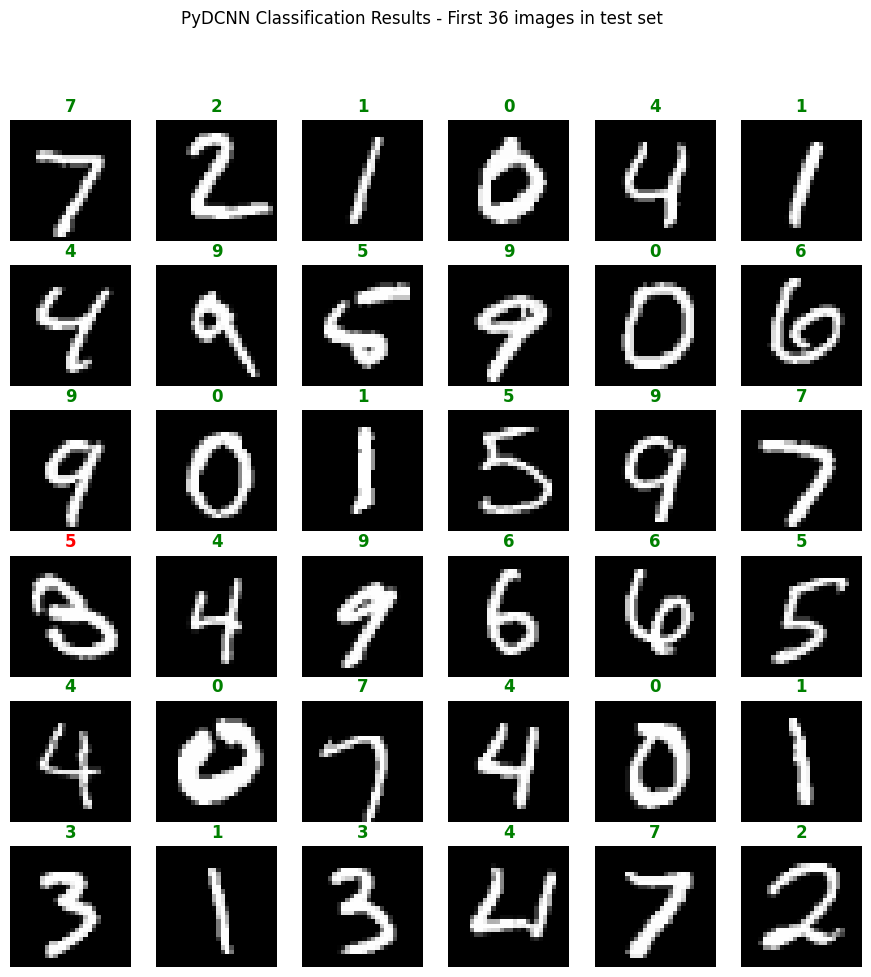

In [ ]:
img_count = 36  # how many images to preview from our training dataset

# calculate square dimensions for subplots
dim = math.ceil(math.sqrt(img_count))
fig, axes = plt.subplots(dim, dim, figsize=(11,11))

for i in range(img_count):

  # grab ith image
  input = test_data[i][0]
  label = test_data[i][1]

  # set input to use current device
  input = input.to(device)

  # add batch dimension to the input tensor
  input = input.unsqueeze(0)

  # run inference on input image
  prediction = cnn.predict(input)

  # isolate corresponding subplot
  ax = axes[i//dim%dim, i%dim]

  # put ith image from training_data into subplot
  input = input.squeeze(0) # remove batch dimension
  img = F.to_pil_image(input)
  ax.imshow(img, cmap='Greys_r', interpolation='none')
  ax.axis('off')

  # set title to show classification result
  color = 'red' if prediction != label else 'green'
  ax.set_title(prediction.item(), color=color, fontweight='bold')

fig.suptitle(f"PyDCNN Classification Results - First {img_count} images in test set")
plt.show()

It's pretty satisfying to see the results after spending all that time designing and training this model.

It looks like the model did a great job of classifying these digits. I set up the title of each image to turn red in case in the case of an incorrect classification. This makes it easy to notice that the model misidentified one sample: the 19th digit appears to be a 3, but the model classified it as a 5.